In [15]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

In [2]:
dfRead = pd.read_csv(r"Analyse/data.csv")
print (len(dfRead))
#print (dfRead.columns.tolist())
#spaltenList = ['datum', 'stunde', 'qualitaetsniveau_windgeschwindigkeit', 'windgeschwindigkeit', 'windrichtung', 'pm10']
df = dfRead.copy()
print (df.columns.tolist())
print(df.dtypes)

394488
['station', 'datum', 'stunde', 'datumstunde', 'qualitaetsniveau_temperatur', 'temperatur', 'luftfeuchtigkeit', 'qualitaetsniveau_windgeschwindigkeit', 'windgeschwindigkeit', 'windrichtung', 'qualitaetsniveau_luftfeuchtigkeit', 'absolute_feuchtigkeit', 'dampfdruck', 'feuchttemperatur', 'luftdruck', 'temperatur_2m', 'relative_luftfeuchtigkeit', 'taupunkttemperatur', 'qualitaetsniveau_niederschlag', 'niederschlagshoehe_mm', 'niederschlag_indikator', 'niederschlagsart', 'qualitaetsniveau_sonneneinstrahlung', 'sonnenscheindauer_minuten', 'qualitaetsniveau_bewoelkung', 'messart_bewoelkung', 'gesamtbewoelkung', 'o3', 'no2', 'pm10']
station                                   int64
datum                                    object
stunde                                    int64
datumstunde                               int64
qualitaetsniveau_temperatur             float64
temperatur                              float64
luftfeuchtigkeit                        float64
qualitaetsniveau_windges

In [3]:
df['datum'] = pd.to_datetime(df['datum'], errors='coerce')
df.set_index('datum', inplace=True)
print(df.index)

DatetimeIndex(['1980-01-01', '1980-01-03', '1980-01-12', '1980-01-17',
               '1980-01-20', '1980-01-21', '1980-01-31', '1980-02-05',
               '1980-02-08', '1980-02-12',
               ...
               '1986-12-31', '1986-12-31', '1986-12-31', '1986-12-31',
               '1986-12-31', '1986-12-31', '1986-12-31', '1986-12-31',
               '1986-12-31', '1986-12-31'],
              dtype='datetime64[ns]', name='datum', length=394488, freq=None)


<Axes: xlabel='datum'>

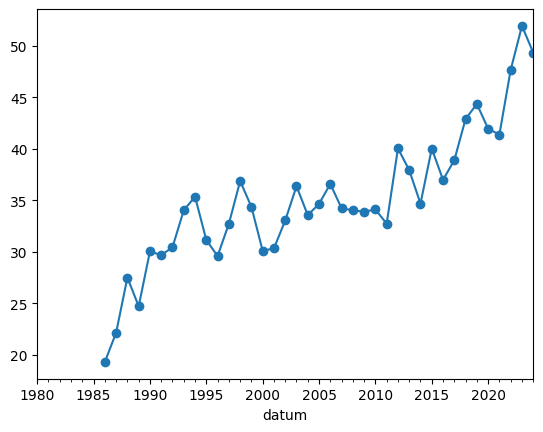

In [18]:
# Jahresmittelwert nur berechnen, wenn das Jahr zu 80% vollständig ist
min_hours_per_year = int(8760 * 0.80)
#spalte = 'pm10'
spalte = 'o3'
annual_trend = df[spalte].resample('YE').apply(lambda x: x.mean() if x.notna().sum() >= min_hours_per_year else None)

annual_trend.plot(marker='o')


['station', 'stunde', 'datumstunde', 'qualitaetsniveau_temperatur', 'temperatur', 'luftfeuchtigkeit', 'qualitaetsniveau_windgeschwindigkeit', 'windgeschwindigkeit', 'windrichtung', 'qualitaetsniveau_luftfeuchtigkeit', 'absolute_feuchtigkeit', 'dampfdruck', 'feuchttemperatur', 'luftdruck', 'temperatur_2m', 'relative_luftfeuchtigkeit', 'taupunkttemperatur', 'qualitaetsniveau_niederschlag', 'niederschlagshoehe_mm', 'niederschlag_indikator', 'niederschlagsart', 'qualitaetsniveau_sonneneinstrahlung', 'sonnenscheindauer_minuten', 'qualitaetsniveau_bewoelkung', 'messart_bewoelkung', 'gesamtbewoelkung', 'o3', 'no2', 'pm10']
station                                   int64
stunde                                    int64
datumstunde                               int64
qualitaetsniveau_temperatur             float64
temperatur                              float64
luftfeuchtigkeit                        float64
qualitaetsniveau_windgeschwindigkeit    float64
windgeschwindigkeit                     

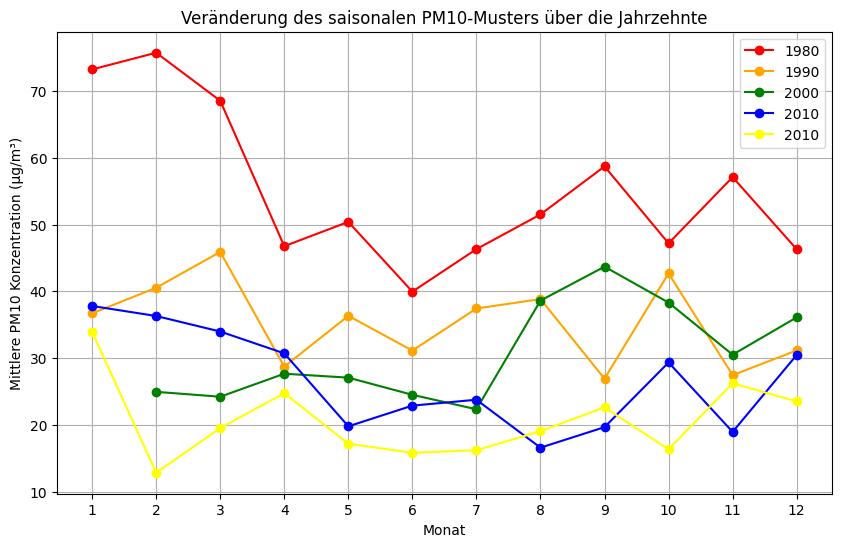

In [5]:
print (df.columns.tolist())
print(df.dtypes)
## Methode: Saisonaler Mittelwert im Langzeitvergleich
# Gruppieren nach Jahr und Monat, um den Mittelwert zu berechnen
monthly_means = df.groupby([df.index.year, df.index.month])['pm10'].mean().unstack()

# Plotten der Kurven für ausgewählte Jahrzehnte zum Vergleich
plt.figure(figsize=(10, 6))
plt.plot(monthly_means.loc[1980], label='1980', color='red', marker='o')
plt.plot(monthly_means.loc[1990], label='1990', color='orange', marker='o')
plt.plot(monthly_means.loc[2000], label='2000', color='green', marker='o')
plt.plot(monthly_means.loc[2010], label='2010', color='blue', marker='o')
plt.plot(monthly_means.loc[2020], label='2010', color='yellow', marker='o')

plt.title('Veränderung des saisonalen PM10-Musters über die Jahrzehnte')
plt.xlabel('Monat')
plt.ylabel('Mittlere PM10 Konzentration (µg/m³)')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)
plt.show()

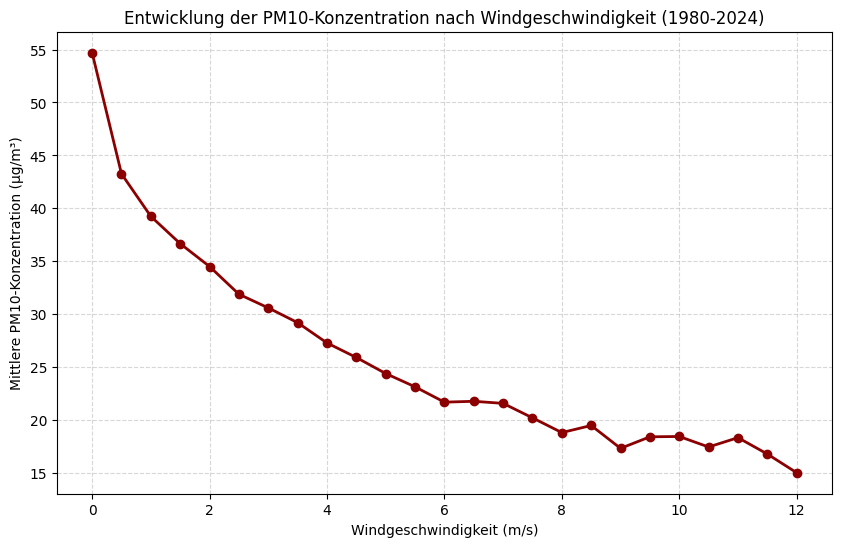

In [6]:
#Entwicklung pm10 zur windgeschwindigkeit
# 1. Windgeschwindigkeit in 0.5 m/s Intervalle (Bins) einteilen
# Ersetzen Sie 'ws' durch den exakten Namen Ihrer Windgeschwindigkeits-Spalte
df['ws_bin'] = np.round(df['windgeschwindigkeit'] * 2) / 2

# 2. Mittleren PM10-Wert pro Windintervall berechnen
# Lücken (NaN) werden von .groupby().mean() automatisch ignoriert
ws_pm10_relation = df.groupby('ws_bin')['pm10'].mean().reset_index()

# 3. Nur Intervalle mit ausreichend Datenpunkten anzeigen (z.B. extreme Stürme filtern)
counts = df.groupby('ws_bin')['pm10'].count()
valid_bins = counts[counts > 100].index
ws_pm10_relation = ws_pm10_relation[ws_pm10_relation['ws_bin'].isin(valid_bins)]

# 4. Plotten
plt.figure(figsize=(10, 6))
plt.plot(ws_pm10_relation['ws_bin'], ws_pm10_relation['pm10'], marker='o', linewidth=2, color='darkred')
plt.title('Entwicklung der PM10-Konzentration nach Windgeschwindigkeit (1980-2024)')
plt.xlabel('Windgeschwindigkeit (m/s)')
plt.ylabel('Mittlere PM10-Konzentration (µg/m³)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Spearman-Korrelation im Winter: -0.48
Spearman-Korrelation im Sommer: 0.07


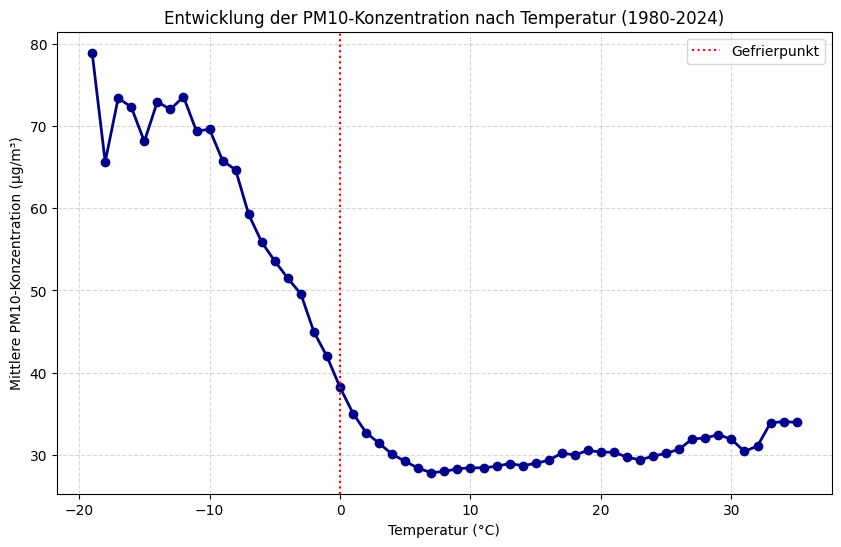

In [13]:
# TEMPERATUR ANALYSE
# Daten in Winter (Jan, Feb, Dez) und Sommer (Jun, Jul, Aug) trennen
winter_df = df[df.index.month.isin([12, 1, 2])]
sommer_df = df[df.index.month.isin([6, 7, 8])]

print(f"Spearman-Korrelation im Winter: {winter_df['pm10'].corr(winter_df['temperatur'], method='spearman'):.2f}")
print(f"Spearman-Korrelation im Sommer: {sommer_df['pm10'].corr(sommer_df['temperatur'], method='spearman'):.2f}")

# 1. Temperatur in 1°C-Schritte runden
# Ersetzen Sie 'temp' durch den exakten Namen Ihrer Temperatur-Spalte
df['temp_bin'] = np.round(df['temperatur'])

# 2. Mittleren PM10-Wert pro Temperaturstufe berechnen
temp_pm10_relation = df.groupby('temp_bin')['pm10'].mean().reset_index()

# 3. Extreme Ausreißer (z.B. Temperaturen, die seltener als 50-mal vorkamen) filtern
counts = df.groupby('temp_bin')['pm10'].count()
valid_bins = counts[counts > 50].index
temp_pm10_relation = temp_pm10_relation[temp_pm10_relation['temp_bin'].isin(valid_bins)]

# 4. Plotten
plt.figure(figsize=(10, 6))
plt.plot(temp_pm10_relation['temp_bin'], temp_pm10_relation['pm10'], marker='o', linewidth=2, color='darkblue')
plt.title('Entwicklung der PM10-Konzentration nach Temperatur (1980-2024)')
plt.xlabel('Temperatur (°C)')
plt.ylabel('Mittlere PM10-Konzentration (µg/m³)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(x=0, color='red', linestyle=':', label='Gefrierpunkt')
plt.legend()
plt.show()

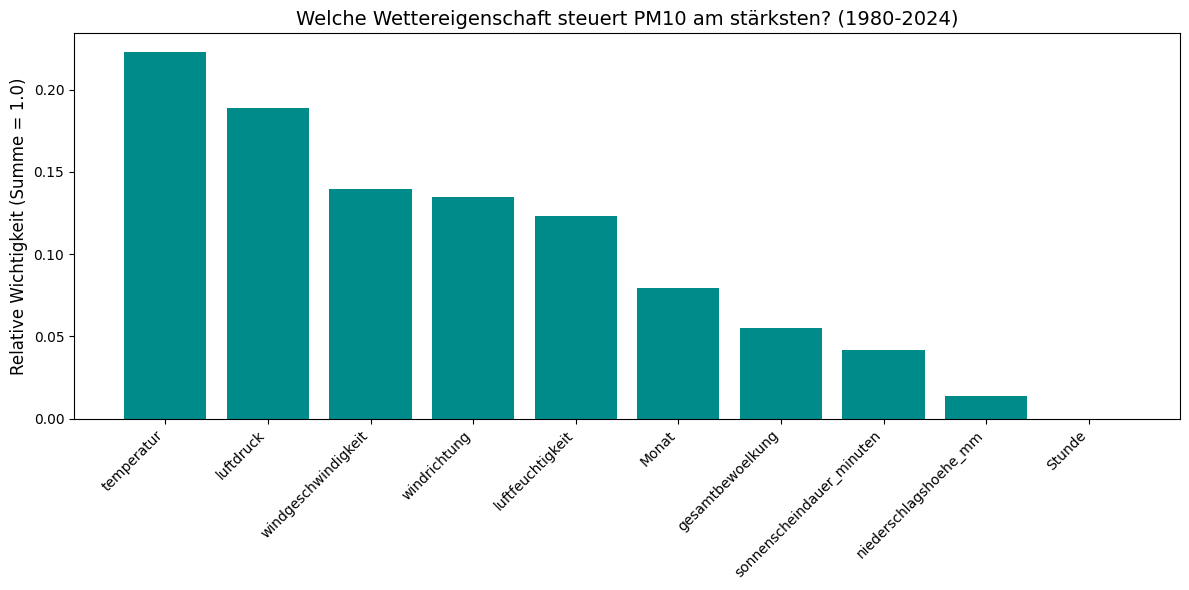

Die Top 3 wichtigsten Einflussfaktoren auf PM10:
1. temperatur (22.3%)
2. luftdruck (18.9%)
3. windgeschwindigkeit (14.0%)


In [16]:
# 1. Relevante Wetterspalten für die Analyse auswählen
wetter_features = [
    'temperatur', 'luftfeuchtigkeit', 'windgeschwindigkeit', 
    'windrichtung', 'luftdruck', 'niederschlagshoehe_mm', 
    'sonnenscheindauer_minuten', 'gesamtbewoelkung'
]

# Zeitkomponenten hinzufügen, damit das Modell saisonale Trends versteht
df['Monat'] = df.index.month
df['Stunde'] = df.index.hour
all_features = wetter_features + ['Monat', 'Stunde']

# 2. Datensatz bereinigen (nur Zeilen ohne Lücken für diesen Schritt nutzen)
analysis_df = df[all_features + ['pm10']].dropna()

X = analysis_df[all_features]
y = analysis_df['pm10']

# 3. Random Forest Modell trainieren (Nutzt alle CPU-Kerne für Schnelligkeit)
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X, y)

# 4. Feature Importance extrahieren und sortieren
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# 5. Ergebnisse visualisieren
plt.figure(figsize=(12, 6))
plt.title("Welche Wettereigenschaft steuert PM10 am stärksten? (1980-2024)", fontsize=14)
plt.bar(range(X.shape[1]), importances[indices], color="darkcyan", align="center")
plt.xticks(range(X.shape[1]), [all_features[i] for i in indices], rotation=45, ha='right')
plt.ylabel("Relative Wichtigkeit (Summe = 1.0)", fontsize=12)
plt.tight_layout()
plt.show()

# Textausgabe der Top 3
print("Die Top 3 wichtigsten Einflussfaktoren auf PM10:")
for i in range(3):
    print(f"{i+1}. {all_features[indices[i]]} ({importances[indices[i]]*100:.1f}%)")